# 유방암 데이터셋

---

## 데이터셋의 목적

이 데이터셋의 주 목적은 **유방 종양의 미세침 흡인 세포(FNA) 이미지에서 추출한 특징들을 바탕으로, 해당 종양이 악성(Malignant)인지 양성(Benign)인지 예측**하는 것입니다.


* **`malignant` (악성, 암이 맞음):** 보통 머신러닝에서 레이블 `0`으로 표현됩니다.
* **`benign` (양성, 단순 종양):** 보통 머신러닝에서 레이블 `1`으로 표현됩니다.

> ⚠️ **주의:** 사이킷런 데이터셋에서는 특이하게 **양성(Benign)이 1, 악성(Malignant)이 0**으로 매핑되어 있습니다. 보통 질병 유무를 따질 때 질병이 있는 상태를 `1`로 두는 경우가 많아 헷갈리기 쉬우니 데이터 분석 시 꼭 확인해야 합니다.

---

## 데이터 구조 및 스펙

전체적인 데이터의 크기와 구조는 다음과 같습니다.

* **전체 샘플 수 (행, Rows):** 569개
* 악성(Malignant): 212개
* 양성(Benign): 357개


* **특징 수 (열, Columns/Features):** 30개

---

## 30개의 특징(Features)은 어떻게 만들어졌을까?

종양 세포 핵의 디지털 이미지에서 **10가지 핵심 측정값**을 컴퓨터로 계산해 낸 것입니다.

| 핵심 측정값 (10개) | 설명 |
| --- | --- |
| **`radius`** | 중심에서 외곽선까지의 거리 평균 |
| **`texture`** | 회색조(Gray-scale) 명암 값의 표준편차 |
| **`perimeter`** | 종양의 둘레 길이 |
| **`area`** | 종양의 면적 |
| **`smoothness`** | 반경 길이의 국소적 변화 (부드러운 정도) |
| **`compactness`** | $\frac{\text{perimeter}^2}{\text{area}} - 1.0$ (조밀한 정도) |
| **`concavity`** | 윤곽선에서 오목한 부분의 심한 정도 |
| **`concave points`** | 윤곽선 중 오목한 부분의 개수 |
| **`symmetry`** | 대칭성 |
| **`fractal dimension`** | 프랙탈 차원 (외곽선의 복잡도) |

이 **10가지 측정값** 각각에 대해 통계적인 수치인 **평균(mean), 표준오차(error), 가장 큰 값의 평균(worst)** 3가지를 곱하여 총 30개($10 \times 3$)의 피처가 구성됩니다.

* *예시: `mean radius`, `radius error`, `worst radius` ... 이런 식으로 30개가 존재합니다.*


In [33]:
import pandas as pd, numpy as np, seaborn as sb, matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.datasets import load_breast_cancer


# ── 데이터 로드 ──────────────────────────────────────────────────
data = load_breast_cancer()
print("target_names:", data.target_names)
# ['malignant' 'benign']  ← index 0=악성, index 1=정상

# ⚠ 주의: target=0이 malignant(악성), target=1이 benign(정상)!
# 직관과 반대 → y = 1 - data.target 으로 뒤집어서 사용
# y=1: 악성(malignant), y=0: 정상(benign)
y_cancer = 1 - data.target
X_cancer = data.data

target_names: ['malignant' 'benign']



---
### train, test 데이터 분리

In [4]:
train_input, test_input, train_target, test_target = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

print(train_input.shape)
print(test_input.shape)
print(train_target.mean())
print(test_target.mean())

(455, 30)
(114, 30)
0.37362637362637363
0.3684210526315789



---
### StandardScaler

In [14]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_input)
test_scaled = scaler.transform(test_input)

In [15]:
print(train_scaled[:3])

[[ 5.18558727e-01  8.91825791e-01  4.24631702e-01  3.83925436e-01
  -9.74743706e-01 -6.89771505e-01 -6.88586446e-01 -3.98175254e-01
  -1.03915470e+00 -8.25056321e-01 -1.09317755e-01 -5.59755400e-02
  -2.10096206e-01 -1.59132582e-02 -1.00518399e+00 -9.11941990e-01
  -6.62815884e-01 -6.52561081e-01 -7.01889114e-01 -2.75393571e-01
   5.79797697e-01  1.31324246e+00  4.66908134e-01  4.45982711e-01
  -5.96154777e-01 -6.34722227e-01 -6.10227299e-01 -2.35743918e-01
   5.45663235e-02  2.18367276e-02]
 [-5.16364088e-01 -1.63971029e+00 -5.41348716e-01 -5.42961327e-01
   4.76219058e-01 -6.31833818e-01 -6.04281166e-01 -3.03074908e-01
   5.21543093e-01 -4.54522896e-01 -6.04377961e-01 -1.00104604e+00
  -5.85429002e-01 -4.93453793e-01  4.03212009e-01 -7.68173276e-01
  -4.79187222e-01  1.14508478e-01 -1.42950761e-01 -5.77397732e-01
  -5.82458953e-01 -1.69029101e+00 -6.11934288e-01 -5.87013537e-01
   2.73581959e-01 -8.14844486e-01 -7.12666415e-01 -3.23207881e-01
  -1.37576237e-01 -9.04401643e-01]
 [-3.6


---
### LogisticRegression

In [16]:
lr = LogisticRegression()

# 모델 학습
lr.fit(train_scaled, train_target)

print(lr.classes_)
print(lr.coef_)
print(lr.intercept_)

[0 1]
[[ 0.36115007  0.4822194   0.35315987  0.43995028  0.35062156 -0.43954615
   0.78229835  0.95281283 -0.16399087 -0.08086512  1.23332517 -0.40761126
   0.74829471  0.90902906  0.24799098 -0.9069248  -0.09234069  0.48208908
  -0.33065773 -0.59387632  0.89696783  1.43409317  0.72311148  0.90047661
   0.42020675 -0.17348751  0.9114058   0.70399881  1.06126366  0.05486988]]
[-0.24300533]


In [17]:
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9868131868131869
0.9649122807017544


In [18]:
# 결정 함수
decisions = lr.decision_function(train_scaled[:3])
decisions

array([ 2.74921149, -6.68747416, -7.15450632])


---
#### Sigmoid

In [19]:
from scipy.special import expit

proba = expit(decisions)
print(proba)

[9.39868802e-01 1.24487543e-03 7.80725182e-04]


In [24]:
pred = lr.predict(test_scaled)
pred

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1])

In [23]:
proba = lr.predict_proba(test_scaled)[:, 1]
proba

array([3.64568116e-04, 9.99999989e-01, 4.25679471e-02, 5.76187322e-01,
       5.09155489e-01, 6.16001620e-04, 7.61534086e-01, 1.01217174e-03,
       5.68725516e-04, 1.07675795e-02, 9.30905953e-01, 7.28319772e-05,
       9.99999899e-01, 4.39449272e-03, 7.75262630e-03, 1.70641370e-06,
       6.14294329e-02, 3.62811536e-04, 2.21762013e-01, 5.07279789e-05,
       1.26622816e-03, 4.30342121e-03, 9.99999581e-01, 9.98321524e-01,
       7.57606906e-01, 2.05880632e-04, 1.68680282e-04, 9.69171419e-01,
       9.96639529e-01, 9.99579644e-01, 9.99991854e-01, 2.37027672e-03,
       9.99964222e-01, 9.99954679e-01, 2.66371788e-04, 1.39030746e-02,
       2.02020415e-03, 3.20211147e-06, 9.90930715e-01, 9.31932725e-02,
       1.25745605e-04, 3.52528144e-04, 8.52325081e-01, 2.51409506e-03,
       1.08172442e-02, 9.54067888e-01, 7.56926419e-02, 9.98508631e-01,
       5.69898683e-05, 1.11541174e-03, 9.99999992e-01, 9.98457814e-01,
       7.12763094e-03, 1.05057651e-03, 1.21417298e-04, 9.88025845e-01,
      

In [25]:
c = confusion_matrix(test_target, pred)
c

array([[71,  1],
       [ 3, 39]])

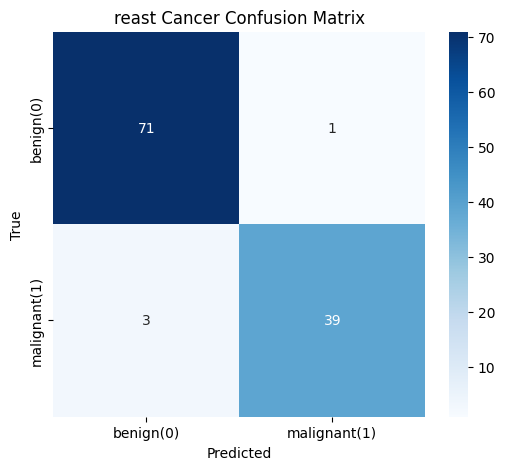

In [36]:
plt.figure(figsize=(6,5))

sb.heatmap(c, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["benign(0)", "malignant(1)"],
            yticklabels=["benign(0)", "malignant(1)"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("reast Cancer Confusion Matrix")
plt.show()

In [27]:
print(classification_report(test_target, pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
auc = roc_auc_score(test_target, proba)
print(auc)

0.996031746031746


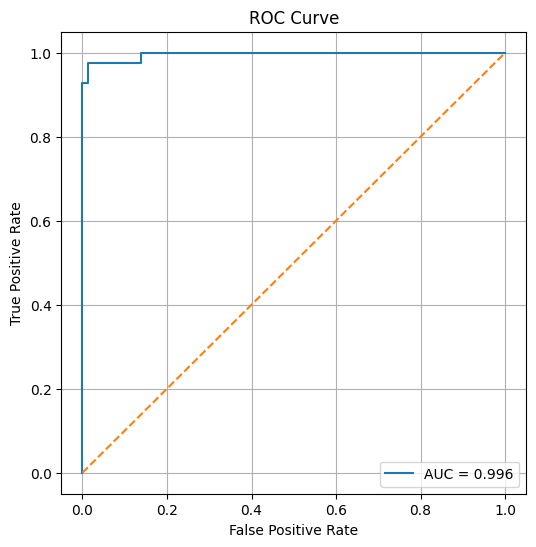

In [35]:
# ROC Curve 계산
fpr, tpr, thresholds = roc_curve(test_target, proba)

# 시각화
plt.figure(figsize=(6, 6))

# ROC Curve
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

# 랜덤 기준선
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()